# Multiple Linear Regression

In [21]:
from sklearn.datasets import make_regression
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

import plotly.express as px
import plotly.graph_objects as go

import seaborn as sns


In [11]:
X,y  = make_regression(n_samples=100,n_features=2,n_informative=2,n_targets=1,noise=50)

In [12]:
# convert into dataframe
df = pd.DataFrame({'f1':X[:,0],'f2':X[:,1],'target':y})

In [13]:
df

,f1,f2,target
0,0.698918,-0.940642,-30.629352
1,0.843925,-0.439065,161.759827
2,1.354582,0.840464,144.214166
3,-0.630997,-1.396677,49.693221
4,1.227641,-1.601477,-2.576094
...,...,...,...
95,1.916319,0.353300,109.652632
96,-0.298636,0.068121,-52.472179
97,-1.292015,0.430339,-13.637748
98,1.764168,-1.430895,101.304277


In [14]:
df.shape

(100, 3)

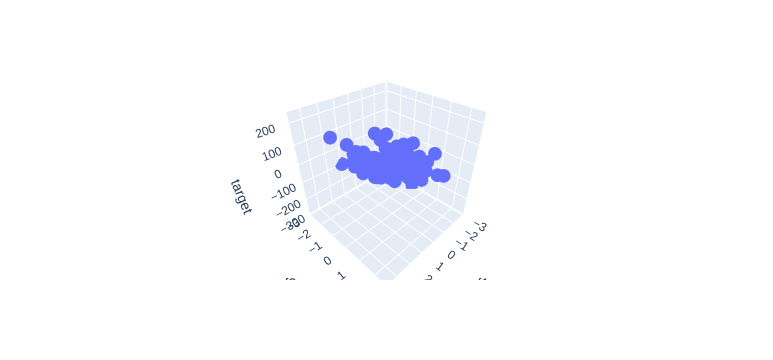

In [15]:
# plot the data
fig  =px.scatter_3d(df ,x='f1',y='f2',z ='target')
fig.show()

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [17]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
# prediction
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
print("MSE",mean_squared_error(y_test,y_pred))
print("MAE",mean_absolute_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))

MSE 1839.5072220138388
MAE 34.40381982283352
R2 score 0.7876448005971983


In [24]:
# plot a hyperplane 
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(y, x)
final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T
z_final = model.predict(final).reshape(10,10)

z = z_final


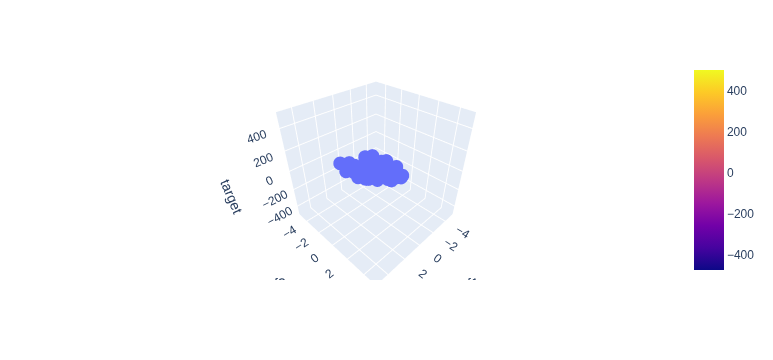

In [25]:
fig = px.scatter_3d(df, x='f1', y='f2', z='target')
fig.add_trace(go.Surface(x = x, y = y, z =z ))
fig.show()

## code from Scratch

In [26]:
import numpy as np
from sklearn.datasets import load_diabetes

X,y = load_diabetes(return_X_y =True)

In [27]:
X

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]], shape=(442, 10))

In [28]:
y

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

In [29]:
X.shape

(442, 10)

In [30]:
y.shape

(442,)

In [31]:
# use sklearn
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [32]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
# prediction
from sklearn.metrics import r2_score
y_pred = model.predict(X_test)
score = r2_score(y_test,y_pred)
print(score)

0.4526027629719195


In [34]:
model.coef_

array([  37.90402135, -241.96436231,  542.42875852,  347.70384391,
       -931.48884588,  518.06227698,  163.41998299,  275.31790158,
        736.1988589 ,   48.67065743])

In [35]:
model.intercept_

np.float64(151.34560453985995)

## creating class from scratch

In [36]:
class own_LR:

    # constructor 
    def __init__(self):
        self.coef =None
        self.intercept = None

    def fit(self,X_train,y_train):
        X_train =np.insert(X_train,0,1,axis=1)

        # calculate inverse
        beta =np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
        self.intercept = beta[0]
        self.coef = beta[1:]

    def predict(self,X_test):
        y_pred =np.dot(X_test,self.coef)+self.intercept
        return y_pred

In [37]:
mm = own_LR()
mm.fit(X_train,y_train)

In [38]:
X_train.shape

(353, 10)

In [40]:
y_pred =mm.predict(X_test)

In [41]:
r2_score(y_test,y_pred)

0.4526027629719199

In [42]:
mm.coef

array([  37.90402135, -241.96436231,  542.42875852,  347.70384391,
       -931.48884588,  518.06227698,  163.41998299,  275.31790158,
        736.1988589 ,   48.67065743])

In [43]:
mm.intercept

np.float64(151.34560453986003)